## Cubic Spline Interpolation

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Known data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

# Step sizes
h = np.diff(x)

In [16]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

In [41]:
A, B, C, D = setup_tridiagonal_matrix(x, y)
#print(A,B,C,D)

[1. 1. 1. 1.] [4. 4. 4. 4.] [1. 1. 1. 1.] [-7.  7. -7.  7.]


In [43]:
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x
M = thomas_algorithm(A,B,C,D)
M=np.concatenate(([0],M,[0]))
print(len(M))

6


In [54]:
# Solving for the spline curve
spline=[]
l=len(M)
sx=[]
for i in range(0,l-1):
    for j in np.arange(x[i],x[i+1]+0.1,0.1):
        term1=(M[i]/(6*h[i]))*(x[i+1]-j)**3
        term2=(M[i+1]/(6*h[i]))*(j-x[i])**3
        term3=(y[i]/h[i] - M[i]*h[i]/6)*(x[i+1]-j)
        term4=(y[i+1]/h[i] - M[i+1]*h[i]/6)*(j-x[i])
        sp=term1+term2+term3+term4
        spline.append(sp)
        sx.append(j)

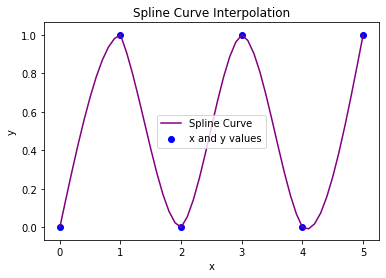

In [55]:
plt.figure()
plt.scatter(x,y,label='x and y values',color='blue')
plt.plot(sx,spline,label='Spline Curve',color='purple')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Spline Curve Interpolation')
plt.legend()
plt.show()